# 👥 Adult Census Income – Codificación de Variables Categóricas
## Machine Learning I · Aplica técnicas de codificación de variables categóricas

---

Este notebook aplica y compara tres técnicas de codificación de variables categóricas  
sobre el dataset Adult Census Income (UCI), preparando los datos para futuros modelos de ML.

| Paso | Descripción |
|------|-------------|
| 1️⃣ | Carga y análisis exploratorio (EDA) |
| 2️⃣ | Codificación con `pd.get_dummies` |
| 3️⃣ | Codificación con `OneHotEncoder` (scikit-learn) |
| 4️⃣ | Codificación con `LabelEncoder` (scikit-learn) |
| 5️⃣ | Comparación de métodos |

> **Dataset:** `dataset.csv` — 32561 registros · 15 columnas (9 categóricas + 6 numéricas)  
> **Objetivo:** clasificar si el ingreso anual es `<=50K` o `>50K`  
> **Salida:** `machine_learning.ipynb` + `comparacion_metodos.md`


---
## 📖 README — Configuración del entorno

| Variable de entorno | Descripción | Valor por defecto |
|---------------------|-------------|-------------------|
| `ADULT_INPUT` | Ruta al CSV de entrada | `/workspace/dataset.csv` |

**Linux / macOS:**
```bash
export ADULT_INPUT=/mi/ruta/dataset.csv
jupyter notebook machine_learning.ipynb
```

**Windows (PowerShell):**
```powershell
$env:ADULT_INPUT = "C:\mi\ruta\dataset.csv"
```

> ⚠️ El CSV no tiene fila de cabecera — los nombres de columna se asignan en la carga.


## 0. Importación de librerías

In [114]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

INPUT_PATH = os.getenv("ADULT_INPUT", "workspace/dataset.csv")
print(f"📂 Input: {INPUT_PATH}")
print("✅ Librerías cargadas correctamente")


📂 Input: workspace/dataset.csv
✅ Librerías cargadas correctamente


---
## 1. Análisis Exploratorio de Datos (EDA)

### 1.1 Carga del dataset

El CSV no incluye fila de cabecera, por lo que los nombres de columna se asignan manualmente  
según la documentación del UCI Adult Dataset.


In [115]:
COLUMNAS = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race",
    "sex", "capital_gain", "capital_loss", "hours_per_week",
    "native_country", "income"
]

df = pd.read_csv(INPUT_PATH, header=None, names=COLUMNAS)

# Limpiar espacios en variables de texto (el CSV incluye espacios tras la coma)
cols_str = df.select_dtypes(include="object").columns
df[cols_str] = df[cols_str].apply(lambda c: c.str.strip())

print(f"📐 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")


📐 Dimensiones: 32561 filas × 15 columnas


C:\Users\macdu\AppData\Local\Temp\ipykernel_6216\3265647572.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_str = df.select_dtypes(include="object").columns


### 1.2 Primeras filas (`df.head()`)

In [116]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### 1.3 Información general (`df.info()`)

In [117]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


### 1.4 Estadísticas descriptivas

In [118]:
df.describe().round(2)

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.00,32561.00,32561.00,32561.00,32561.00,32561.00
mean,38.58,189778.37,10.08,1077.65,87.30,40.44
std,13.64,105549.98,2.57,7385.29,402.96,12.35
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117827.00,9.00,0.00,0.00,40.00
50%,37.00,178356.00,10.00,0.00,0.00,40.00
75%,48.00,237051.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


### 1.4b Estadísticas descriptivas — variables categóricas

`df.describe(include='object')` muestra frecuencia, valor más común y número de categorías únicas.

In [119]:
df.describe(include='object')

C:\Users\macdu\AppData\Local\Temp\ipykernel_6216\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


### 1.5 Identificación de variables categóricas y numéricas

Tabla combinada con tipo de dato, número de valores únicos y porcentaje de nulos.


In [120]:
cols_cat = df.select_dtypes(include="object").columns.tolist()
cols_num = df.select_dtypes(include="number").columns.tolist()

info_df = pd.DataFrame({
    "Tipo":          df.dtypes,
    "Únicos":        df.nunique(),
    "Nulos":         df.isnull().sum(),
    "% Nulos":       (df.isnull().sum() / len(df) * 100).round(2),
})
print(f"📋 Variables categóricas ({len(cols_cat)}): {cols_cat}")
print(f"📋 Variables numéricas   ({len(cols_num)}): {cols_num}")
print()
print(info_df.to_string())


C:\Users\macdu\AppData\Local\Temp\ipykernel_6216\1085839749.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_cat = df.select_dtypes(include="object").columns.tolist()


📋 Variables categóricas (9): ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']
📋 Variables numéricas   (6): ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

                 Tipo  Únicos  Nulos  % Nulos
age             int64      73      0      0.0
workclass         str       9      0      0.0
fnlwgt          int64   21648      0      0.0
education         str      16      0      0.0
education_num   int64      16      0      0.0
marital_status    str       7      0      0.0
occupation        str      15      0      0.0
relationship      str       6      0      0.0
race              str       5      0      0.0
sex               str       2      0      0.0
capital_gain    int64     119      0      0.0
capital_loss    int64      92      0      0.0
hours_per_week  int64      94      0      0.0
native_country    str      42      0      0.0
income            str       2      0      0.0


### 1.5b Valores faltantes explícitos

El dataset Adult codifica los valores faltantes como `'?'` en lugar de `NaN`. Los identificamos de ambas formas.

In [121]:
# Nulos reales (NaN)
print("🔍 Nulos reales (NaN) por columna:")
print(df.isnull().sum().to_string())

# El dataset Adult usa '?' para representar desconocidos
print()
print("🔍 Valores '?' por columna (codificación de faltantes del dataset):")
for col in cols_cat:
    n = (df[col] == "?").sum()
    if n > 0:
        print(f"  {col:20s}: {n} valores '?' ({n/len(df)*100:.2f}%)")


🔍 Nulos reales (NaN) por columna:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0

🔍 Valores '?' por columna (codificación de faltantes del dataset):
  workclass           : 1836 valores '?' (5.64%)
  occupation          : 1843 valores '?' (5.66%)
  native_country      : 583 valores '?' (1.79%)


### 1.5c Tratamiento de valores '?' — conversión a NaN

Reemplazamos `'?'` por `NaN` para que los modelos y las funciones de pandas los traten como faltantes reales.
Trabajamos sobre `df_clean` preservando `df` original intacto.

In [122]:
df_clean = df.replace("?", np.nan)

print("🔍 Nulos tras reemplazar '?' por NaN:")
nulos = df_clean.isnull().sum()
nulos_df = nulos[nulos > 0].to_frame("Nulos")
nulos_df["% del total"] = (nulos_df["Nulos"] / len(df_clean) * 100).round(2)
print(nulos_df.to_string())

print(f"\nOpción A — eliminar filas con NaN: {df_clean.dropna().shape[0]} filas restantes")
print(f"Opción B — imputar con la moda:     mantiene {len(df_clean)} filas")

# Imputamos con la moda (estrategia conservadora para no perder datos)
for col in df_clean.select_dtypes(include="object").columns:
    if df_clean[col].isnull().any():
        moda = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(moda)
        print(f"  ✅ {col:20s}: imputado con moda='{moda}'")

print(f"\n📐 df_clean listo: {df_clean.shape} — 0 nulos")


🔍 Nulos tras reemplazar '?' por NaN:


C:\Users\macdu\AppData\Local\Temp\ipykernel_6216\389760172.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include="object").columns:


                Nulos  % del total
workclass        1836         5.64
occupation       1843         5.66
native_country    583         1.79

Opción A — eliminar filas con NaN: 30162 filas restantes
Opción B — imputar con la moda:     mantiene 32561 filas
  ✅ workclass           : imputado con moda='Private'
  ✅ occupation          : imputado con moda='Prof-specialty'
  ✅ native_country      : imputado con moda='United-States'

📐 df_clean listo: (32561, 15) — 0 nulos


### 1.6 Distribución de variables categóricas — gráficos de barras

Un gráfico de barras por cada variable categórica para ver la distribución de sus categorías.


C:\Users\macdu\AppData\Local\Temp\ipykernel_6216\1921728082.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=serie.to_frame(col), y=col, order=orden,
C:\Users\macdu\AppData\Local\Temp\ipykernel_6216\1921728082.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=serie.to_frame(col), y=col, order=orden,
C:\Users\macdu\AppData\Local\Temp\ipykernel_6216\1921728082.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=serie.to_frame(col), y=col, order=orden,
C:\Users\macdu\AppData\Local\Temp\ipykernel_6216\1921728082.py:1

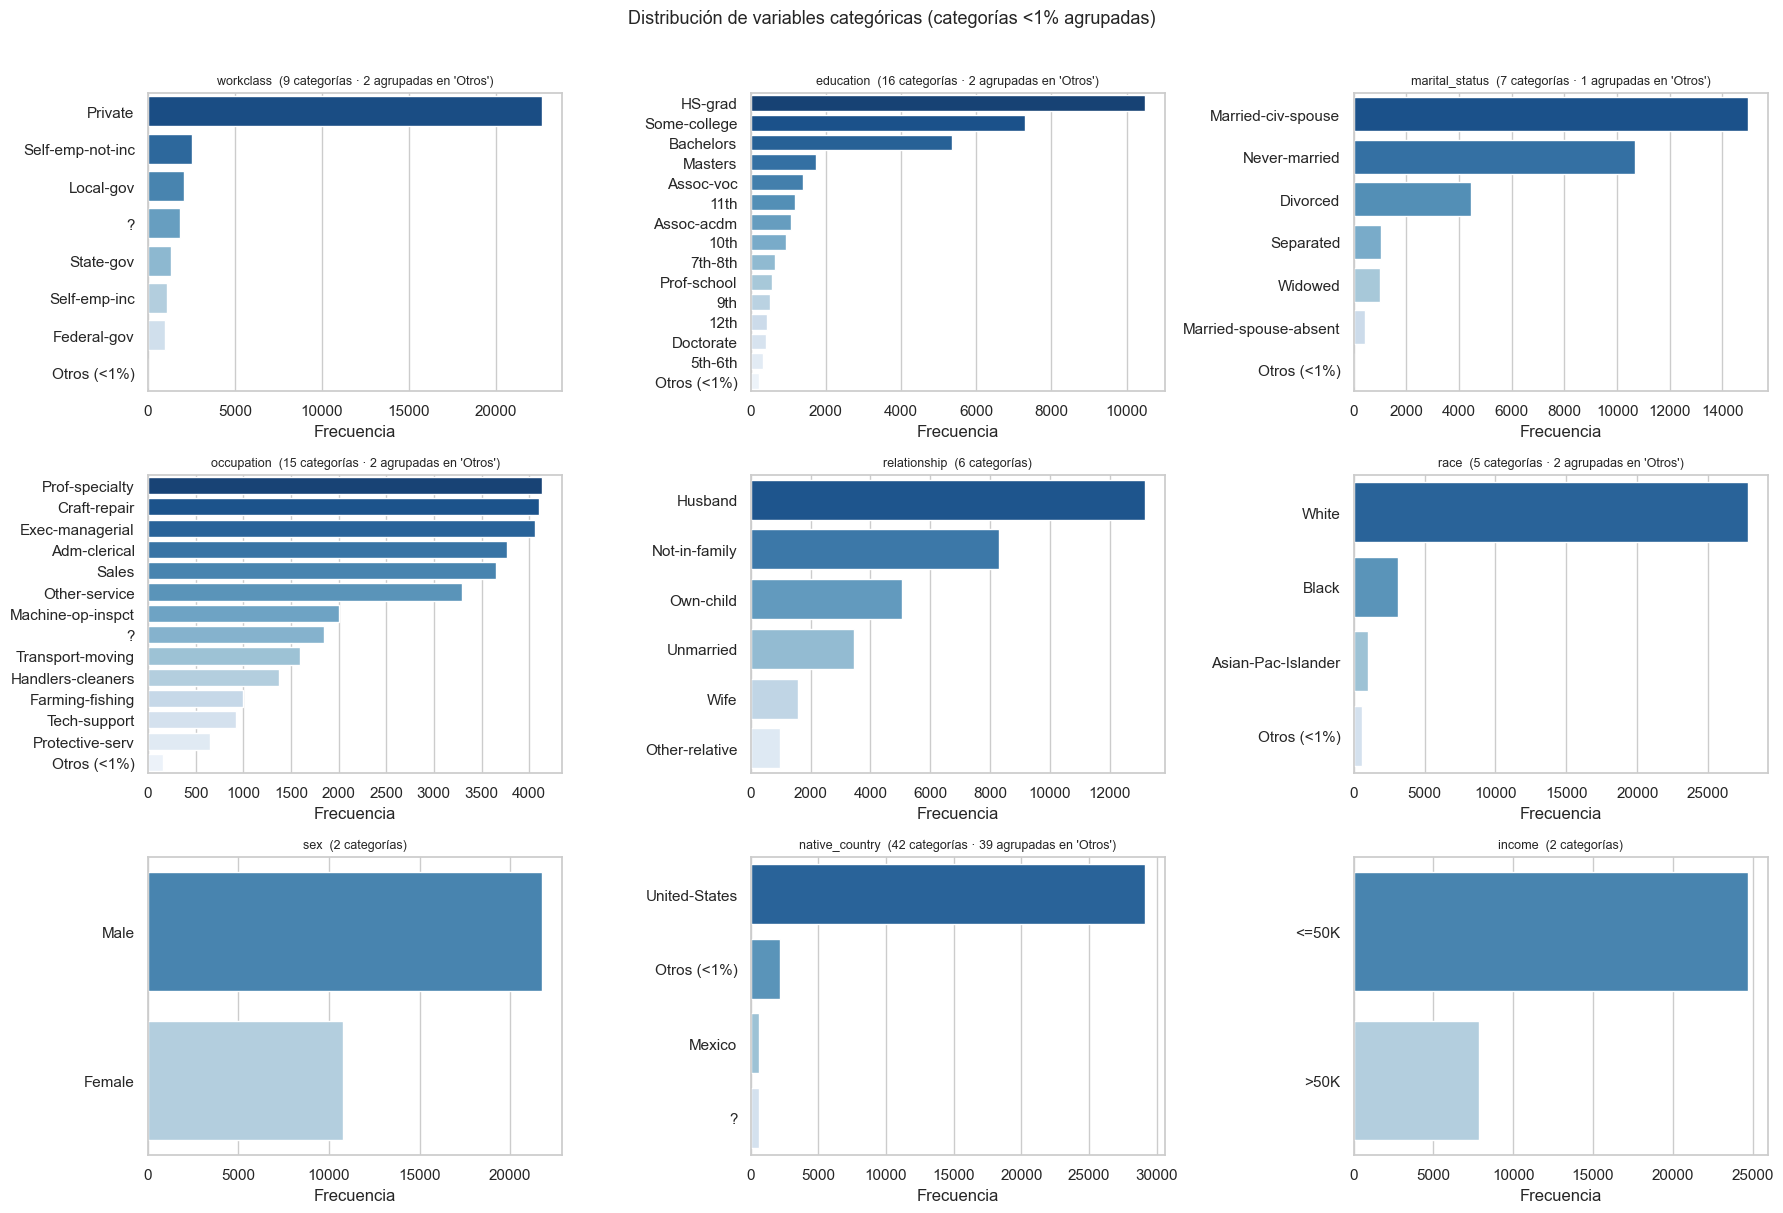

In [123]:
UMBRAL_RARO = 0.01  # categorías con < 1% se agrupan en "Otros"

n_cols_plot = 3
n_rows_plot = -(-len(cols_cat) // n_cols_plot)
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, n_rows_plot * 4))
axes = axes.flatten()

for idx, col in enumerate(cols_cat):
    freq = df[col].value_counts(normalize=True)
    cats_raras = freq[freq < UMBRAL_RARO].index
    serie = df[col].copy()
    if len(cats_raras) > 0:
        serie = serie.replace(cats_raras, "Otros (<1%)")
    orden = serie.value_counts().index
    sns.countplot(data=serie.to_frame(col), y=col, order=orden,
                  ax=axes[idx], palette="Blues_r")
    titulo = f"{col}  ({df[col].nunique()} categorías"
    if len(cats_raras) > 0:
        titulo += f" · {len(cats_raras)} agrupadas en 'Otros'"
    axes[idx].set_title(titulo + ")", fontsize=9)
    axes[idx].set_xlabel("Frecuencia")
    axes[idx].set_ylabel("")

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Distribución de variables categóricas (categorías <{UMBRAL_RARO*100:.0f}% agrupadas)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 1.7 Distribución de variables numéricas — histogramas


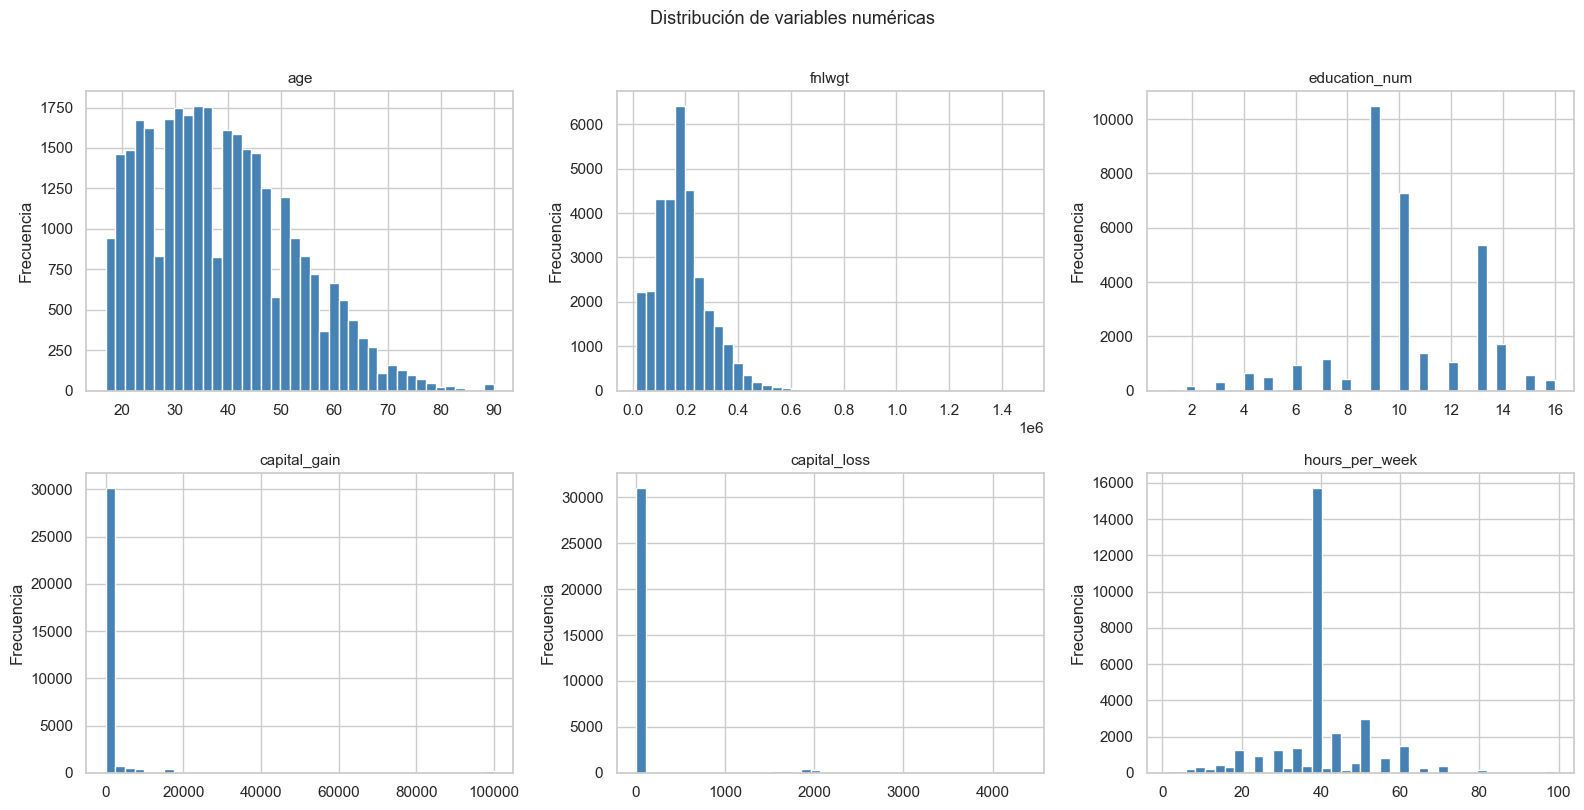

In [124]:
n_cols_plot = 3
n_rows_plot = -(-len(cols_num) // n_cols_plot)

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, n_rows_plot * 4))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    df[col].hist(ax=axes[i], bins=40, color="steelblue", edgecolor="white")
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel("Frecuencia")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de variables numéricas", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 1.8 Detección de outliers — boxplots de variables numéricas


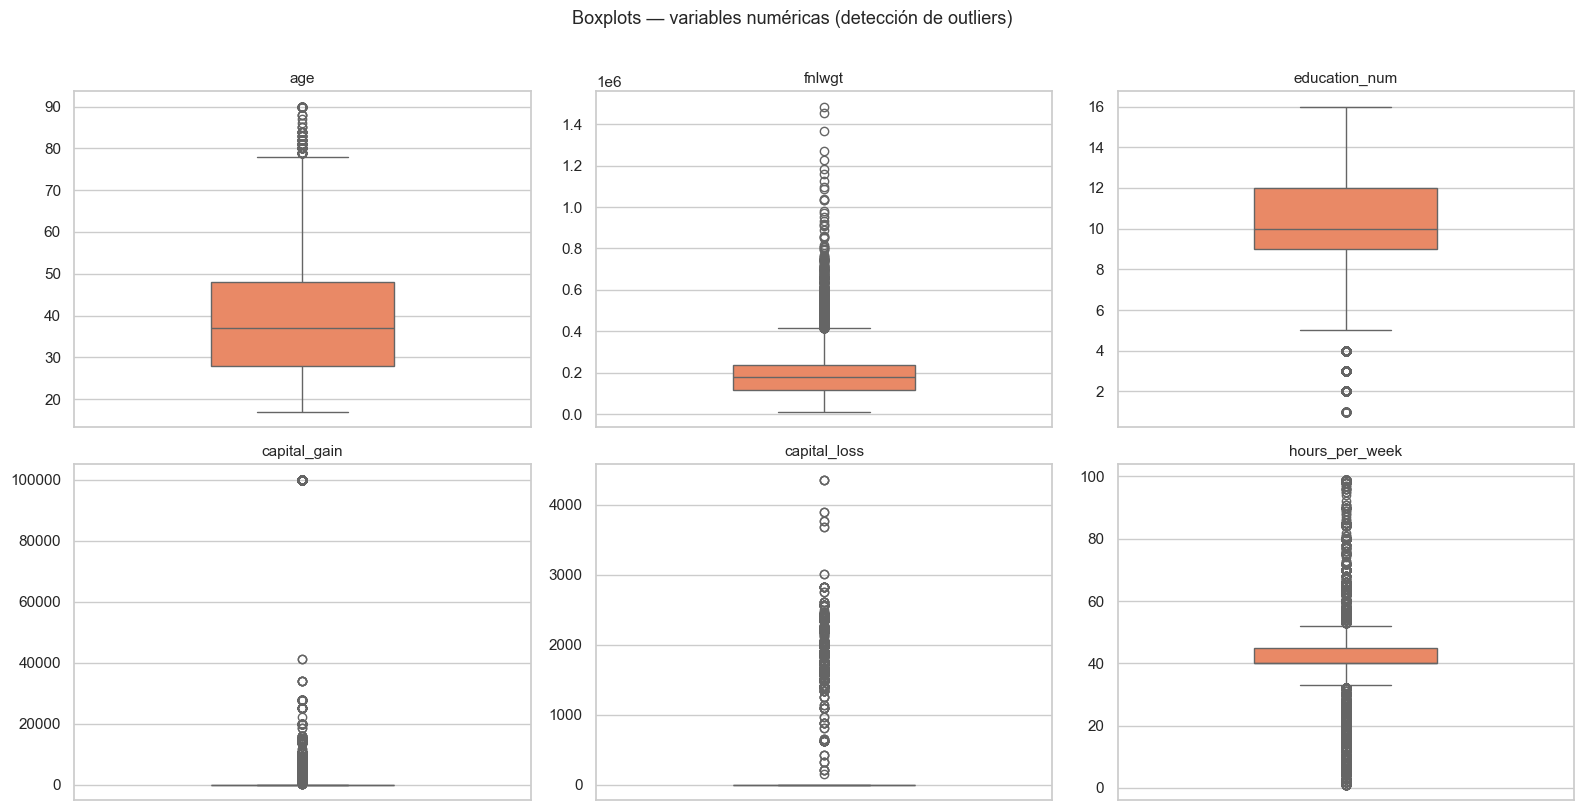

In [125]:
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, n_rows_plot * 4))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    sns.boxplot(data=df, y=col, ax=axes[i], color="coral", width=0.4)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots — variables numéricas (detección de outliers)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


**Interpretación de outliers detectados:**

| Variable | Outliers | Interpretación |
|----------|----------|----------------|
| `capital_gain` | Muchos valores extremos altos | La mayoría son 0 (sin plusvalía); los valores altos corresponden a contribuyentes con ganancias de capital significativas — distribución muy sesgada |
| `capital_loss` | Similar a `capital_gain` | Misma lógica: la mayoría son 0 y unos pocos registros tienen pérdidas considerables |
| `fnlwgt` | Cola derecha larga | Peso estadístico de la muestra — algunos registros representan poblaciones muy pequeñas con pesos altos |
| `hours_per_week` | Valores extremos en ambos extremos | Jornadas muy cortas (< 10h) o muy largas (> 80h) son posibles pero infrecuentes |
| `age` | Sin outliers graves | Distribución razonablemente normal entre 17 y 90 años |

> `capital_gain` y `capital_loss` merecen tratamiento especial antes del modelado (transformación logarítmica o binarización) dado que más del 90% de los registros tienen valor 0.


---
## 2. Codificación con `pd.get_dummies`

`pd.get_dummies` convierte cada categoría en una columna binaria (0/1) directamente desde pandas,  
sin necesidad de instanciar ningún objeto. Usamos `drop_first=True` para evitar multicolinealidad.


In [126]:
df_dummies = pd.get_dummies(df, columns=cols_cat, drop_first=True, dtype=int)

print(f"📐 Shape original:      {df.shape}")
print(f"📐 Shape tras dummies:  {df_dummies.shape}")
print(f"📋 Nuevas columnas añadidas: {df_dummies.shape[1] - df.shape[1] + len(cols_cat)}")
print()
# Mostrar las columnas generadas para la primera variable categórica
cols_gen = [c for c in df_dummies.columns if c.startswith("workclass_")]
print(f"Ejemplo — columnas generadas para 'workclass': {cols_gen}")


📐 Shape original:      (32561, 15)
📐 Shape tras dummies:  (32561, 101)
📋 Nuevas columnas añadidas: 95

Ejemplo — columnas generadas para 'workclass': ['workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay']


Vista previa de las columnas binarias generadas para `workclass` — verificación de la codificación:

In [127]:
print(f"Columnas generadas para 'workclass': {cols_gen}")
print()
df_dummies[cols_gen].head(10)


Columnas generadas para 'workclass': ['workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay']



,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,0
2,0,0,0,1,0,0,0,0
3,0,0,0,1,0,0,0,0
4,0,0,0,1,0,0,0,0
5,0,0,0,1,0,0,0,0
6,0,0,0,1,0,0,0,0
7,0,0,0,0,0,1,0,0
8,0,0,0,1,0,0,0,0
9,0,0,0,1,0,0,0,0


In [128]:
df_dummies.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia,income_>50K
0,39,77516,13,2174,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,50,83311,13,0,0,13,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,38,215646,9,0,0,40,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
3,53,234721,7,0,0,40,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
4,28,338409,13,0,0,40,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


---
## 3. Codificación con `OneHotEncoder` (scikit-learn)

`OneHotEncoder` de scikit-learn es el estándar para pipelines de ML.  
Ofrece más control que `get_dummies`: manejo de categorías desconocidas, integración con `Pipeline`, etc.  
Usamos `drop='first'` (equivalente a `drop_first=True`) y `sparse_output=False` para obtener un array denso.


In [129]:
ohe = OneHotEncoder(drop="first", sparse_output=False, dtype=int)

# Fit y transform sobre las columnas categóricas
X_cat_ohe = ohe.fit_transform(df[cols_cat])

# Nombres de las columnas generadas
ohe_feature_names = ohe.get_feature_names_out(cols_cat)

# Combinar con columnas numéricas
df_ohe = pd.concat([
    df[cols_num].reset_index(drop=True),
    pd.DataFrame(X_cat_ohe, columns=ohe_feature_names)
], axis=1)

print(f"📐 Shape original:    {df.shape}")
print(f"📐 Shape tras OHE:    {df_ohe.shape}")
print(f"📋 Features generados: {len(ohe_feature_names)}")
print()
print("Ejemplo — primeras columnas OHE generadas:")
print(list(ohe_feature_names[:8]))


📐 Shape original:    (32561, 15)
📐 Shape tras OHE:    (32561, 101)
📋 Features generados: 95

Ejemplo — primeras columnas OHE generadas:
['workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay']


In [130]:
df_ohe.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia,income_>50K
0,39,77516,13,2174,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,50,83311,13,0,0,13,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,38,215646,9,0,0,40,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
3,53,234721,7,0,0,40,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
4,28,338409,13,0,0,40,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


---
## 4. Codificación con `LabelEncoder` (scikit-learn)

`LabelEncoder` asigna un entero a cada categoría (0, 1, 2, ...).  
Es adecuado para la **variable objetivo** (`income`) o para variables ordinales,  
pero no para variables nominales en modelos lineales, ya que introduce un orden artificial.


In [131]:
# ⚠️  ADVERTENCIA: df_label_demo es SOLO para demostración del efecto de LabelEncoder.
#    NO usar este DataFrame con modelos lineales (regresión logística, SVM, redes neuronales)
#    porque introduce un orden artificial en variables nominales que distorsiona los coeficientes.
#    Para modelos lineales usar siempre df_ohe (OneHotEncoder).

df_label_demo = df.copy()
label_encoders = {}

# Aplicar LabelEncoder a las variables categóricas predictoras (excluye income)
cols_cat_features = [c for c in cols_cat if c != "income"]

for col in cols_cat_features:
    le = LabelEncoder()
    df_label_demo[col] = le.fit_transform(df_label_demo[col])
    label_encoders[col] = le
    print(f"  {col:20s}: {list(le.classes_)} → {list(range(len(le.classes_)))}")

print(f"\n📐 Shape: {df_label_demo.shape} — mismas dimensiones, columnas sustituidas por enteros")


  workclass           : ['?', 'Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay'] → [0, 1, 2, 3, 4, 5, 6, 7, 8]
  education           : ['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad', 'Masters', 'Preschool', 'Prof-school', 'Some-college'] → [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  marital_status      : ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed'] → [0, 1, 2, 3, 4, 5, 6]
  occupation          : ['?', 'Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving'] → [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
  relationship        : ['Husband', 'Not-in-family', 'Oth

### 4.1 LabelEncoder sobre la variable objetivo `income`

Aplicamos `LabelEncoder` explícitamente sobre `income` y mostramos el mapeo categoría → entero.  
Este es el uso más adecuado de `LabelEncoder`: convertir la variable objetivo binaria en 0/1.


In [132]:
le_income = LabelEncoder()
df_label_demo["income"] = le_income.fit_transform(df_label_demo["income"])

print("📋 Mapeo de la variable objetivo 'income':")
for clase, codigo in zip(le_income.classes_, le_income.transform(le_income.classes_)):
    print(f"  '{clase}'  →  {codigo}")

print()
print(f"Distribución tras encoding:")
print(df_label_demo["income"].value_counts().to_string())


📋 Mapeo de la variable objetivo 'income':
  '<=50K'  →  0
  '>50K'  →  1

Distribución tras encoding:
income
0    24720
1     7841


### 4.2 Ejemplo numérico — orden artificial de LabelEncoder

Ilustramos por qué usar `LabelEncoder` en features nominales introduce un sesgo en modelos lineales.


In [133]:
# Supongamos que codificamos 'workclass' con LabelEncoder:
# Federal-gov=0, Local-gov=1, Private=2, Self-emp-not-inc=3, State-gov=4, ...
#
# Un modelo lineal (ej. regresión logística) calcula:
#   y = w * workclass + ...
#
# Con esta codificación, el modelo infiere que:
#   State-gov (4) > Self-emp-not-inc (3) > Private (2) > Local-gov (1) > Federal-gov (0)
#
# Esto es matemáticamente incorrecto: no existe ninguna relación ordinal entre tipos de empleo.

ejemplo = pd.DataFrame({
    "workclass_original":  ["Federal-gov", "Local-gov",  "Private", "Self-emp-not-inc", "State-gov"],
    "label_encoding":      [0,              1,            2,         3,                  4],
    "diferencia_con_prev": ["—",            "+1",         "+1",      "+1",               "+1"],
    "interpretacion_modelo": [
        "referencia",
        "igual de 'lejos' que Federal-gov",
        "doble distancia que Federal-gov",
        "triple distancia que Federal-gov",
        "cuádruple distancia que Federal-gov"
    ]
})
print("⚠️  Orden artificial introducido por LabelEncoder en 'workclass':\n")
print(ejemplo.to_string(index=False))
print()
print("✅  Con OneHotEncoder cada categoría es una dimensión independiente — sin orden implícito.")


⚠️  Orden artificial introducido por LabelEncoder en 'workclass':

workclass_original  label_encoding diferencia_con_prev               interpretacion_modelo
       Federal-gov               0                   —                          referencia
         Local-gov               1                  +1    igual de 'lejos' que Federal-gov
           Private               2                  +1     doble distancia que Federal-gov
  Self-emp-not-inc               3                  +1    triple distancia que Federal-gov
         State-gov               4                  +1 cuádruple distancia que Federal-gov

✅  Con OneHotEncoder cada categoría es una dimensión independiente — sin orden implícito.


In [134]:
df_label_demo.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,7,77516,9,13,4,1,1,4,1,2174,0,40,39,0
1,50,6,83311,9,13,2,4,0,4,1,0,0,13,39,0
2,38,4,215646,11,9,0,6,1,4,1,0,0,40,39,0
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,39,0
4,28,4,338409,9,13,2,10,5,2,0,0,0,40,5,0


### 4.3 Uso combinado recomendado — OHE en features + LabelEncoder en objetivo

Este es el patrón correcto para un flujo de modelado real:
**`LabelEncoder` solo para `income`** (variable objetivo) y **`OneHotEncoder` para las features categóricas**.

In [135]:
from sklearn.compose import ColumnTransformer

# Variable objetivo: LabelEncoder → entero 0/1
y = LabelEncoder().fit_transform(df_clean["income"])
print("🎯 Variable objetivo codificada:")
print(f"  <=50K → 0: {(y == 0).sum()} registros")
print(f"  >50K  → 1: {(y == 1).sum()} registros")

# Features: OHE para categóricas, pasar numéricas tal cual
cols_cat_feat = [c for c in cols_cat if c != "income"]
preprocessor = ColumnTransformer([
    ("ohe", OneHotEncoder(drop="first", sparse_output=False, dtype=int), cols_cat_feat),
], remainder="passthrough")

X = preprocessor.fit_transform(df_clean)
print(f"\n📐 Shape de X tras ColumnTransformer: {X.shape}")
print(f"📐 Shape de y: {y.shape}")
print("\n✅ Dataset listo para entrenar un modelo — sin orden artificial en features categóricas")


🎯 Variable objetivo codificada:
  <=50K → 0: 24720 registros
  >50K  → 1: 7841 registros

📐 Shape de X tras ColumnTransformer: (32561, 98)
📐 Shape de y: (32561,)

✅ Dataset listo para entrenar un modelo — sin orden artificial en features categóricas


---
## 5. Comparación de Métodos de Codificación

### 5.1 Comparación de dimensiones resultantes


In [136]:
comparacion = pd.DataFrame([
    {"Método":        "Original",
     "Filas":         df.shape[0],
     "Columnas":      df.shape[1],
     "Tipo salida":   "DataFrame mixto",
     "Multicolinealidad": "—"},
    {"Método":        "get_dummies (pandas)",
     "Filas":         df_dummies.shape[0],
     "Columnas":      df_dummies.shape[1],
     "Tipo salida":   "DataFrame binario",
     "Multicolinealidad": "Evitada (drop_first=True)"},
    {"Método":        "OneHotEncoder (sklearn)",
     "Filas":         df_ohe.shape[0],
     "Columnas":      df_ohe.shape[1],
     "Tipo salida":   "DataFrame binario",
     "Multicolinealidad": "Evitada (drop='first')"},
    {"Método":        "LabelEncoder (sklearn)",
     "Filas":         df_label_demo.shape[0],
     "Columnas":      df_label_demo.shape[1],
     "Tipo salida":   "DataFrame enteros",
     "Multicolinealidad": "No aplica (ordinal implícito)"},
]).set_index("Método")

print(comparacion.to_string())


                         Filas  Columnas        Tipo salida              Multicolinealidad
Método                                                                                    
Original                 32561        15    DataFrame mixto                              —
get_dummies (pandas)     32561       101  DataFrame binario      Evitada (drop_first=True)
OneHotEncoder (sklearn)  32561       101  DataFrame binario         Evitada (drop='first')
LabelEncoder (sklearn)   32561        15  DataFrame enteros  No aplica (ordinal implícito)


### 5.2 Ventajas y desventajas de cada método

| Método | Ventajas | Desventajas | Cuándo usarlo |
|--------|----------|-------------|---------------|
| **`get_dummies`** | Sintaxis simple · integrado en pandas · no requiere fit/transform | No reutilizable en producción (no guarda el estado del encoding) | Exploración rápida, notebooks de análisis |
| **`OneHotEncoder`** | Integrable en `Pipeline` · maneja categorías desconocidas (`handle_unknown`) · serializable | Más verboso · requiere instanciar objeto | Pipelines de producción, train/test split |
| **`LabelEncoder`** | Mantiene dimensionalidad · útil para variable objetivo | Introduce orden artificial entre categorías → sesga modelos lineales | Variable objetivo binaria/ordinal exclusivamente |


### 5.2b Recomendaciones por tipo de modelo

| Tipo de modelo | Encoding recomendado | Motivo |
|----------------|---------------------|--------|
| **Regresión logística / SVM / Redes neuronales** | `OneHotEncoder` | Sensibles al orden y a la escala — el encoding ordinal distorsiona los coeficientes o los pesos |
| **Árboles de decisión / Random Forest / XGBoost** | `LabelEncoder` o `OHE` indistinto | Los árboles realizan splits binarios y no asumen orden entre valores enteros; `LabelEncoder` es suficiente y más eficiente |
| **KNN** | `OneHotEncoder` + escalado | Basado en distancias — el encoding ordinal introduce distancias artificiales; el escalado es obligatorio |
| **Naive Bayes** | `LabelEncoder` | Trabaja con probabilidades por categoría; no asume continuidad entre valores |
| **Gradient Boosting (LightGBM, CatBoost)** | Encoding nativo o `LabelEncoder` | Estos frameworks tienen soporte nativo para categóricas; `OHE` puede empeorar el rendimiento en alta cardinalidad |

> Para este dataset con `native_country` (42 categorías) y `occupation` (15 categorías),  
> en modelos de árbol es preferible `LabelEncoder` por eficiencia; en modelos lineales es obligatorio `OneHotEncoder`.


### 5.2c Guía rápida de decisión — por tipo de tarea

Resumen accionable que enlaza con los ejemplos anteriores del notebook para elegir encoding sin dudas:

| Tipo de tarea | Encoding recomendado | Referencia en este notebook |
|---------------|---------------------|-----------------------------|
| **Clasificación binaria** (e.g. `income ≤50K / >50K`) | `OneHotEncoder` en features + `LabelEncoder` en objetivo | Sección 4.3 — patrón `ColumnTransformer` |
| **Clasificación multi-clase** (3 o más clases, modelo lineal) | `OneHotEncoder` en **todas** las features nominales | Sección 3 — `OneHotEncoder` con `drop='first'` |
| **Clasificación multi-clase** (árbol / ensemble) | `LabelEncoder` o `OHE` indistinto | Sección 5.2b — árboles no asumen orden |
| **Alta cardinalidad** (> 20 categorías, e.g. `occupation` con muchas sub-clases) | `TargetEncoder` o agrupación de categorías raras antes de OHE | Sección 1.6 — `UMBRAL_RARO` ya agrupa categorías < 1 % |

> **Regla de oro:** si el modelo usa gradientes o distancias (regresión logística, SVM, KNN, redes neuronales), usa **`OneHotEncoder`**. Si es un árbol o ensemble, cualquier encoding funciona pero `LabelEncoder` es más eficiente en memoria. El `LabelEncoder` en features nominales con modelos lineales **siempre introduce sesgo** (ver sección 4.2).

### 5.3 Ejemplo empírico — LabelEncoder vs OneHotEncoder en regresión logística

Entrenamos el mismo modelo con cada encoding sobre un subconjunto del dataset
para mostrar numéricamente el impacto en la precisión.

In [137]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

y_bin = LabelEncoder().fit_transform(df_clean["income"])
X_num = df_clean[cols_num].values  # columnas numéricas comunes a ambos experimentos

# ── Experimento A: LabelEncoder en features categóricas ─────────────────────
df_le = df_clean.copy()
for col in cols_cat_feat:
    df_le[col] = LabelEncoder().fit_transform(df_le[col])
X_le = df_le[cols_num + cols_cat_feat].values

# ── Experimento B: OneHotEncoder en features categóricas ────────────────────
X_ohe_raw = OneHotEncoder(drop="first", sparse_output=False).fit_transform(df_clean[cols_cat_feat])
X_ohe = np.hstack([X_num, X_ohe_raw])

results = {}
for nombre, X in [("LabelEncoder", X_le), ("OneHotEncoder", X_ohe)]:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y_bin, test_size=0.2, random_state=42)
    pipe = Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(max_iter=300))])
    pipe.fit(X_tr, y_tr)
    acc = pipe.score(X_te, y_te)
    results[nombre] = round(acc * 100, 2)
    print(f"  {nombre:20s}: accuracy = {acc*100:.2f}%")

diff = results["OneHotEncoder"] - results["LabelEncoder"]
print(f"\n📊 Diferencia de accuracy: {diff:+.2f}% a favor de OneHotEncoder")
print("→ El orden artificial de LabelEncoder introduce ruido en el modelo lineal.")


  LabelEncoder        : accuracy = 82.59%
  OneHotEncoder       : accuracy = 85.48%

📊 Diferencia de accuracy: +2.89% a favor de OneHotEncoder
→ El orden artificial de LabelEncoder introduce ruido en el modelo lineal.


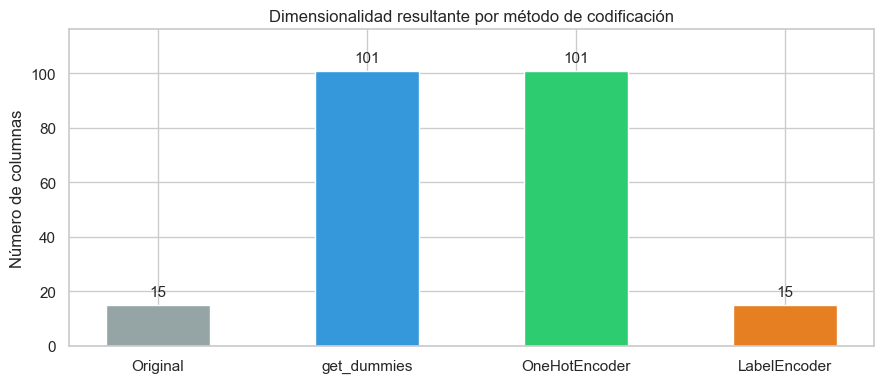

In [138]:
metodos  = ["Original", "get_dummies", "OneHotEncoder", "LabelEncoder"]
columnas = [df.shape[1], df_dummies.shape[1], df_ohe.shape[1], df_label_demo.shape[1]]
colores  = ["#95a5a6", "#3498db", "#2ecc71", "#e67e22"]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(metodos, columnas, color=colores, edgecolor="white", width=0.5)
ax.bar_label(bars, fmt="%d", padding=4, fontsize=11)
ax.set_ylabel("Número de columnas")
ax.set_title("Dimensionalidad resultante por método de codificación", fontsize=12)
ax.set_ylim(0, max(columnas) * 1.15)
plt.tight_layout()
plt.show()


### 5.4 Conclusión

- **`get_dummies`** y **`OneHotEncoder`** producen el mismo resultado (columnas binarias), pero `OneHotEncoder` es preferible en flujos de producción porque es serializable y se integra en `Pipeline`.
- **`LabelEncoder`** no expande dimensionalidad pero solo es adecuado para la variable objetivo (`income`): usar en features nominales introduciría un orden artificial que sesgaría modelos lineales como regresión logística o SVM.
- Para este dataset, el método recomendado para features es **`OneHotEncoder`** dentro de un `ColumnTransformer`, reservando `LabelEncoder` para codificar `income` como 0/1.

> La comparación detallada se encuentra en `comparacion_metodos.md`.


---
## 6. Resumen Final

| Método | Columnas resultantes | Uso recomendado |
|--------|---------------------|----------------|
| `get_dummies` | Variable según dataset | Exploración rápida |
| `OneHotEncoder` | Variable según dataset | Producción / Pipeline |
| `LabelEncoder` | = original | Variable objetivo |
